<a href="https://colab.research.google.com/github/elajeans/IMAG2023/blob/main/oppgave3_py.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Maks feil mot analytisk losning: 6.53e-05


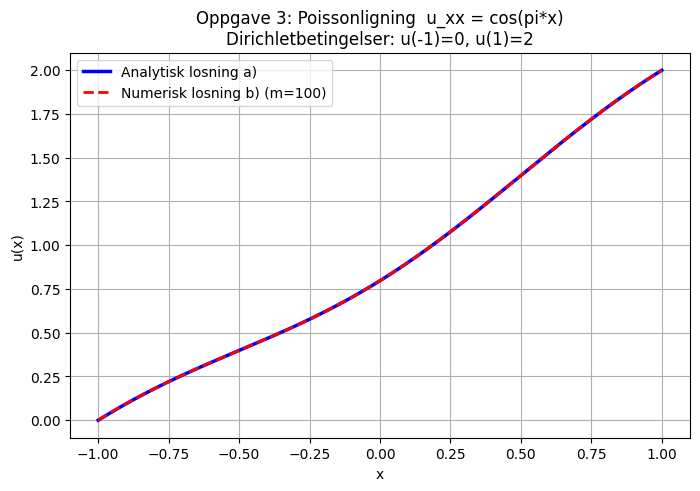

In [55]:
import numpy as np
import matplotlib.pyplot as plt

# OPPGAVE 3: Poissonligning 1D
# Differensiallikning: u_xx = cos(pi*x),  -1 <= x <= 1
#
# Randbetingelser (Dirichletbetingelser):
#   u(-1) = 0   og   u(1) = 2
#
# Dirichletbetingelser = vi setter VERDIEN av losningen pa randen.
# (Ikke den deriverte -- selve funksjonen.)

# DEL A: ANALYTISK LOSNING
# Vi integrerer cos(pi*x) to ganger:
#
#   1. integrasjon:  u'(x) = sin(pi*x)/pi + C1
#   2. integrasjon:  u(x)  = -cos(pi*x)/pi^2 + C1*x + C2
#
# Bruk randbetingelsene (Dirichlet) for a finne C1 og C2:
#
#   u(-1) = 0:   1/pi^2 - C1 + C2 = 0
#   u( 1) = 2:   1/pi^2 + C1 + C2 = 2
#
#   (ii) + (i) => 2*C2 = 2 - 2/pi^2  =>  C2 = 1 - 1/pi^2
#   (ii) - (i) => 2*C1 = 2            =>  C1 = 1
#
#   Analytisk losning:  u(x) = -cos(pi*x)/pi^2 + x + 1 - 1/pi^2

def u_analytisk(x):
    return -np.cos(np.pi * x) / np.pi**2 + x + 1 - 1/np.pi**2



# DEL B: NUMERISK LOSNING (finite differanser)

#------------------------------------------------------------------
# Diskretiser av andrederivert (1D Laplace-operator)
#------------------------------------------------------------------
# Vi ser på intervallet [-1, 1].
# Endepunktene x = -1 og x = 1 er randpunkter.
# m indre punktene brukes som ukjente i det lineære systemet.
#
m = 100                             # antall indre punkter
x = np.linspace(-1, 1, m + 2)       # inkluderer randpunktene
h = x[1] - x[0]                     # steglengde i rom


# Sentral differanse for andrederiverte:
#   u_xx ~ (u_{i-1} - 2*u_i + u_{i+1}) / h^2
#
# Dette gir en tridiagonalt matrise:
#   -2 på hoveddiagonalen
#    1 på øvre og nedre bidiagonal
#
# Matrisen har størrelse m x m, siden vi kun har m indre punkter.
L = (1 / h**2) * (
    np.diag((m - 1) * [1], -1) +
    np.diag(m * [-2], 0) +
    np.diag((m - 1) * [1], 1)
)

# Dirichletbetingelsene paforeres ved a justere hoyreside:
#   b[0]  -= u(-1)/h^2 = 0/h**2
#   b[-1] -= u( 1)/h^2 = 2/h^2

f = np.cos(np.pi * x[1:-1])
b = f.copy()
b[0]  -= 0 / h**2
b[-1] -= 2 / h**2

#Ligningen som skal løses nå er L * u[1:-1] = b
u_inner = np.linalg.solve(L, b)
u = np.concatenate([[0], u_inner, [2]])
u[1:-1] = u_inner

print(f"Maks feil mot analytisk losning: {np.max(np.abs(u - u_analytisk(x))):.2e}")


# Plotting av løsning
#
x_fine = np.linspace(-1, 1, 500)

plt.figure(figsize=(8, 5))
plt.plot(x_fine, u_analytisk(x_fine), 'b-',  linewidth=2.5, label='Analytisk losning a)')
plt.plot(x,      u,                   'r--', linewidth=2,   label=f'Numerisk losning b) (m={m})')
plt.xlabel('x')
plt.ylabel('u(x)')
plt.title('Oppgave 3: Poissonligning  u_xx = cos(pi*x)\nDirichletbetingelser: u(-1)=0, u(1)=2')
plt.legend()
plt.grid(True)
plt.show()


